In [ ]:
!pip install chronos-forecasting pandas matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chronos import Chronos2Pipeline

from google.colab import files
uploaded = files.upload()

In [5]:
inflation = pd.read_excel("WPI_12.xlsx")
inflation.head()

,Month,WPI_inflation_rate
0,2026-02-01,2.13
1,2026-01-01,1.81
2,2025-12-01,0.96
3,2025-11-01,-0.13
4,2025-10-01,-1.02


In [ ]:
inflation.dtypes

,0
Month,datetime64[ns]
WPI_inflation_rate,float64


In [6]:
df=inflation.sort_values("Month")

In [ ]:
df.head()

,Month,WPI_inflation_rate
11,2025-03-01,2.25
10,2025-04-01,0.85
9,2025-05-01,0.13
8,2025-06-01,-0.19
7,2025-07-01,-0.58


In [7]:
df = df.rename(columns={
    "Month": "timestamp",
    "WPI_inflation_rate": "target"
})

In [8]:
df["item_id"] = "inflation_series"

In [9]:
df = df[["item_id", "timestamp", "target"]]

In [10]:
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

In [11]:
pred_df = pipeline.predict_df(df, prediction_length=4)

In [12]:
print(pred_df.head())

            item_id  timestamp target_name  predictions       0.1       0.2  \
0  inflation_series 2026-03-01      target     2.151167  0.536374  1.120922   
1  inflation_series 2026-04-01      target     2.075512  0.065446  0.788021   
2  inflation_series 2026-05-01      target     1.999098 -0.291376  0.559023   
3  inflation_series 2026-06-01      target     1.924252 -0.537027  0.376880   

        0.3       0.4       0.5       0.6       0.7       0.8       0.9  
0  1.516964  1.857378  2.151167  2.431262  2.693182  3.033867  3.633914  
1  1.273655  1.688487  2.075512  2.453237  2.816486  3.319973  4.166924  
2  1.094818  1.563318  1.999098  2.433532  2.873957  3.484287  4.505495  
3  0.972948  1.466498  1.924252  2.413908  2.912086  3.609071  4.757691  


**separating historical and forecast data**

In [13]:
history = df.copy()
forecast = pred_df.copy()

In [16]:
lower = forecast["0.1"] - 0.2
upper = forecast["0.9"] + 0.2

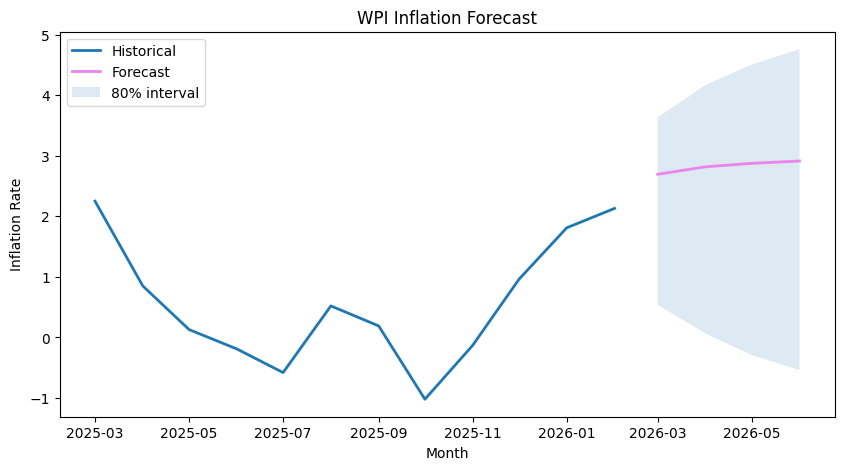

In [14]:
plt.figure(figsize=(10,5))
plt.plot(history["timestamp"], history["target"], label="Historical", linewidth=2)
plt.plot(forecast["timestamp"], forecast["0.7"], label="Forecast", linewidth=2, color="violet")
plt.fill_between(forecast["timestamp"],forecast["0.1"],forecast["0.9"],
alpha=0.15,label="80% interval")
plt.title("WPI Inflation Forecast")
plt.xlabel("Month")
plt.ylabel("Inflation Rate")
plt.legend()
plt.grid(False)
plt.show()

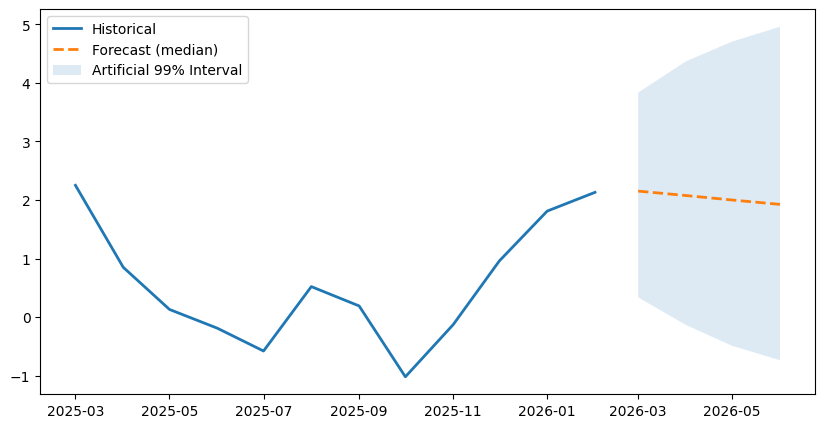

In [17]:
plt.figure(figsize=(10,5))
plt.plot(history["timestamp"], history["target"], label="Historical", linewidth=2)
plt.plot(forecast["timestamp"],forecast["0.5"],label="Forecast (median)",
linestyle="--",linewidth=2)
plt.fill_between(forecast["timestamp"],lower,upper,
alpha=0.15,label="Artificial 99% Interval")
plt.legend()
plt.grid(False)
plt.show()